In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Kardar-Parisi-Zhang Universality Class

This notebook follows examples of the KPZ universiali

In [4]:
Phi, A, B = 0, 1, 2
step = {Phi: np.array([-0.5,  np.sqrt(3) / 2]), A: np.array([-0.5, -np.sqrt(3) / 2]), B: np.array([ 1.0,  0.0])}
names = {Phi: "Phi", A: "A", B: "B"}

In [5]:
r1 = 2.0
r2 = 1.0
r3 = 2.0
r4 = 1.0
r5 = 1.5

r6 = r1 + r4 + r5 - r2 - r3

rates = {(A, B): r1, (B, A): r2, (A, Phi): r3, (Phi, A): r4, (B, Phi): r5, (Phi, B): r6}

In [6]:
L = 90
chain = np.array([Phi] * (L // 3) + [A] * (L // 3) + [B] * (L // 3))
np.random.shuffle(chain)

In [7]:
def monte_carlo_step(chain):
    i = np.random.randint(len(chain))
    j = (i + 1) % len(chain)

    pair = (chain[i], chain[j])
    rate = rates.get(pair, 0.0)

    if np.random.rand() < rate / max(rates.values()):
        chain[i], chain[j] = chain[j], chain[i]

In [8]:
def simulate(chain, steps=5000):
    chain = chain.copy()
    for _ in range(steps):
        monte_carlo_step(chain)
    return chain

In [9]:
def chain_to_path(chain):
    path = [np.array([0.0, 0.0])]
    for x in chain:
        path.append(path[-1] + step[x])
    return np.array(path)

In [11]:
final_chain = simulate(chain, steps=5000)
path = chain_to_path(final_chain)

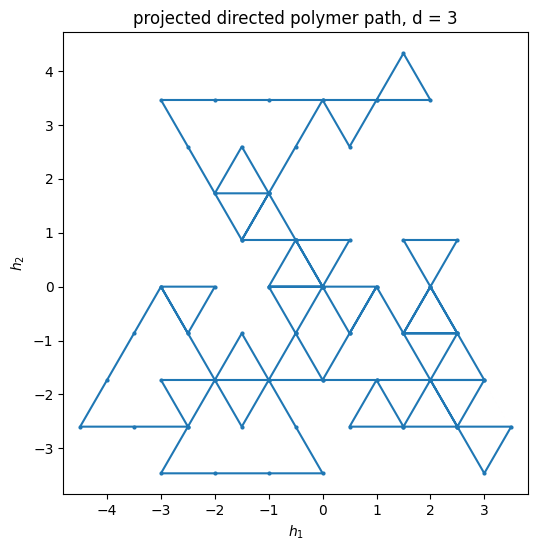

In [12]:
plt.figure(figsize=(6, 6))
plt.plot(path[:, 0], path[:, 1], "-o", markersize=2)
plt.axis("equal")
plt.xlabel("h1")
plt.ylabel("h2")
plt.title("projected directed polymer path, d = 3")
plt.show()

In [26]:
def get_index(i, j):
    m = max(i, j)
    offset = m * (m - 1)
    
    if j == m:
        return offset + 2 * i
    else:  # i == m
        return offset + 2 * j + 1

In [32]:
get_index(3,1)

9

In [34]:
r6

1.5